In [ ]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install -q umap-learn

# **Stage 1 - Install & Imports**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from collections import Counter
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,f1_score

import time
import copy
import json

import cv2
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import umap.umap_ as umap

# Reproducibility Setup

In [ ]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

print("Seed set:", SEED)

Seed set: 42


# Device Setup

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


# Configurations

In [ ]:
batch_size = 32
epochs = 25
learning_rate = 1e-4

img_size_standard = 224     # VGG16 / ResNet50
img_size_inception = 299    # InceptionV3

num_workers = 2
patience = 5

# **Stage 2 — EDA**

In [ ]:

base_path = Path("/kaggle/input/competitions/plant-seedlings-classification")

train_dir = base_path / "train"
test_dir = base_path / "test"

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: /kaggle/input/competitions/plant-seedlings-classification/train
Test path: /kaggle/input/competitions/plant-seedlings-classification/test


# Load Dataset Metadata

In [ ]:
class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
num_classes = len(class_names)

print("Number of classes:", num_classes)
print(class_names)

Number of classes: 12
['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']


# Count Images Per Class (Imbalance Check)

In [ ]:
class_counts = {}

for cls in class_names:
    class_path = train_dir / cls
    class_counts[cls] = len(list(class_path.glob("*")))

class_counts_df = pd.DataFrame.from_dict(
    class_counts, orient="index", columns=["count"]
).sort_values("count", ascending=False)

class_counts_df

,count
Loose Silky-bent,654
Common Chickweed,611
Scentless Mayweed,516
Small-flowered Cranesbill,496
Fat Hen,475
Charlock,390
Sugar beet,385
Cleavers,287
Black-grass,263
Shepherds Purse,231


# Class Distribution Plot

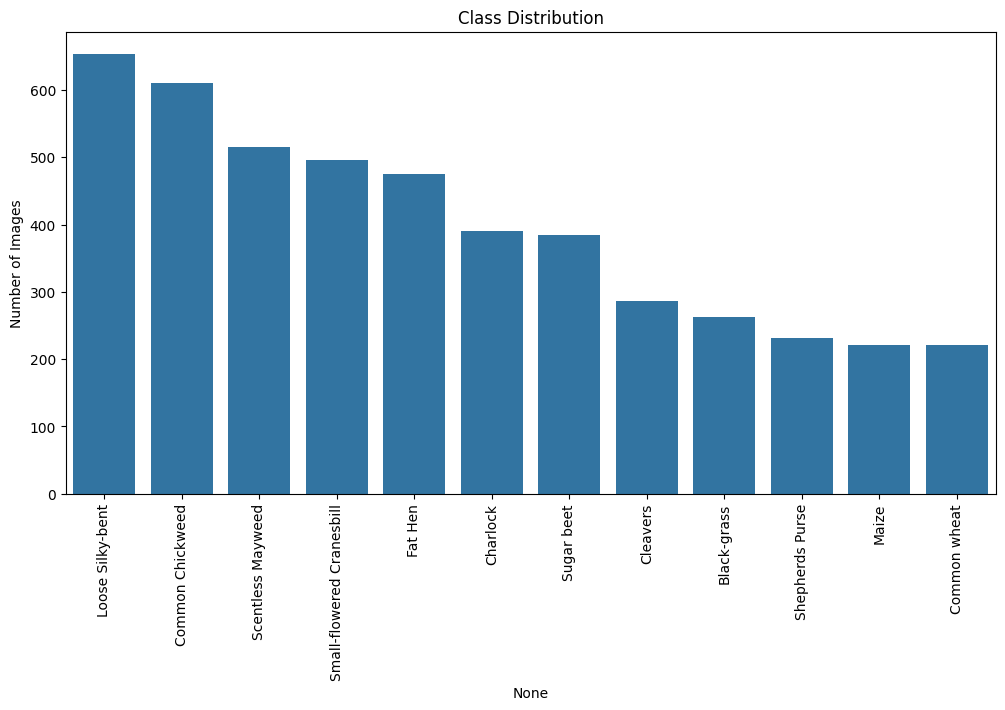

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=class_counts_df.index,
    y=class_counts_df["count"]
)

plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

# Dataset Summary

In [ ]:
total_images = sum(class_counts.values())

print(f"Total Training Images: {total_images}")
print(f"Number of Classes: {num_classes}")
print(f"Average Images per Class: {total_images/num_classes:.2f}")

Total Training Images: 4750
Number of Classes: 12
Average Images per Class: 395.83


# **Visual Inspection (Sample Images per Class)**

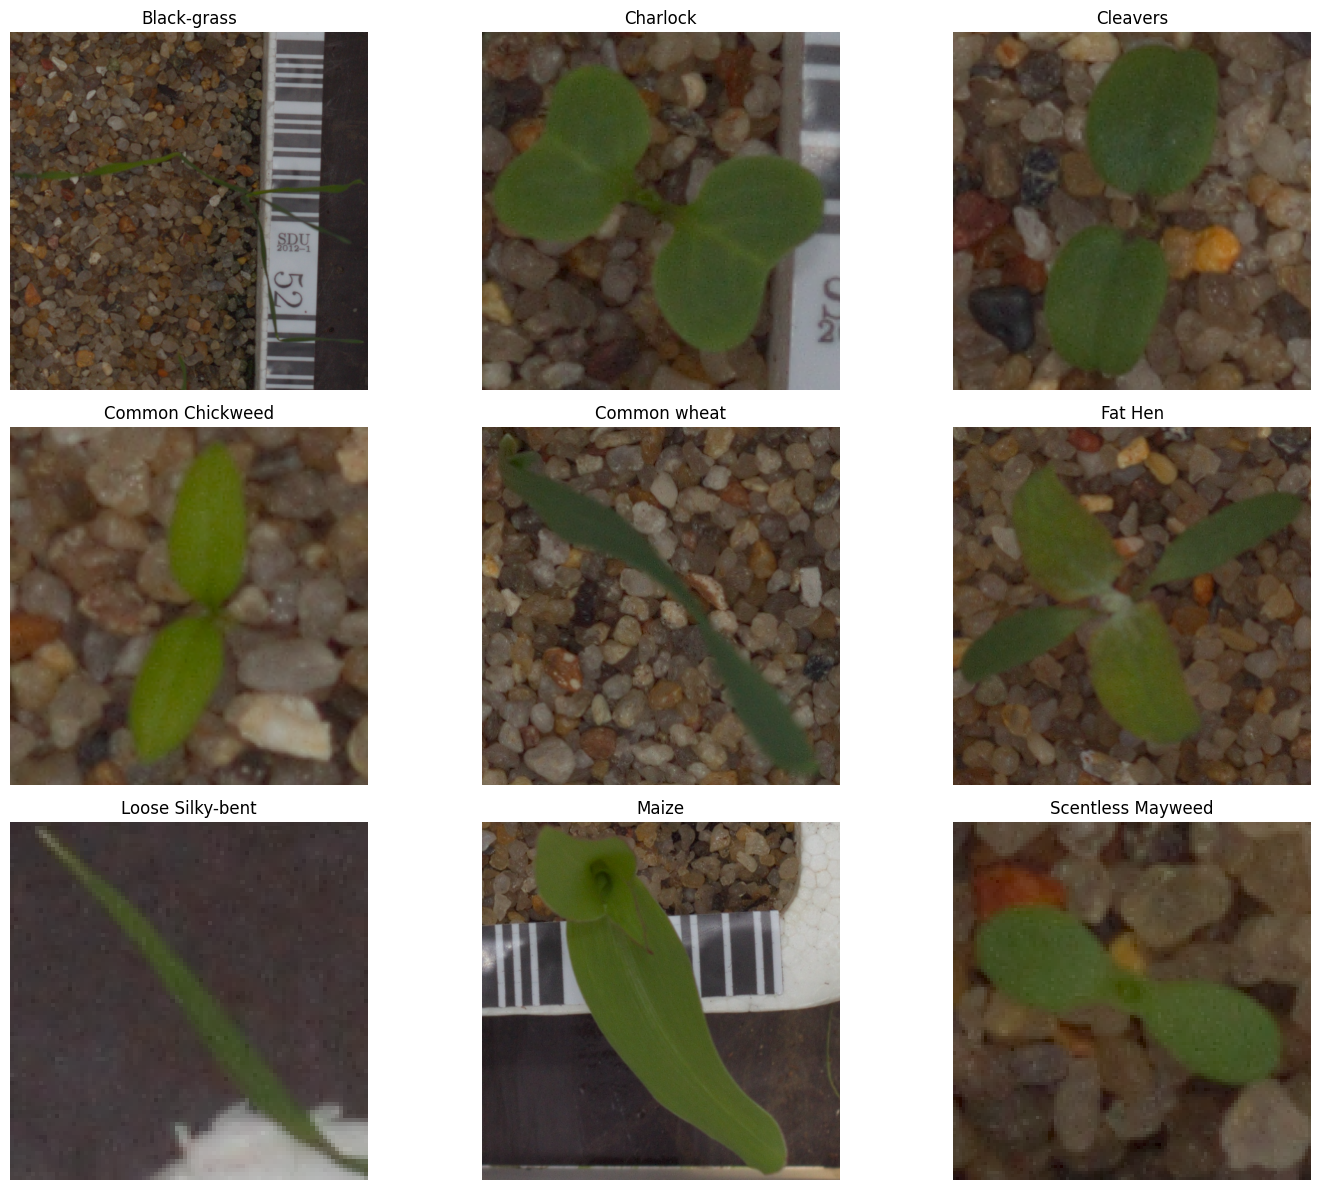

In [ ]:
plt.figure(figsize=(15,12))

for i, cls in enumerate(class_names[:9]):  # first 9 classes
    img_path = random.choice(list((train_dir/cls).glob("*")))
    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Image Size Analysis

In [ ]:
widths = []
heights = []

for cls in class_names:
    for img_path in (train_dir/cls).glob("*"):
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)

print("Width range:", min(widths), "-", max(widths))
print("Height range:", min(heights), "-", max(heights))

Width range: 49 - 3991
Height range: 49 - 3457


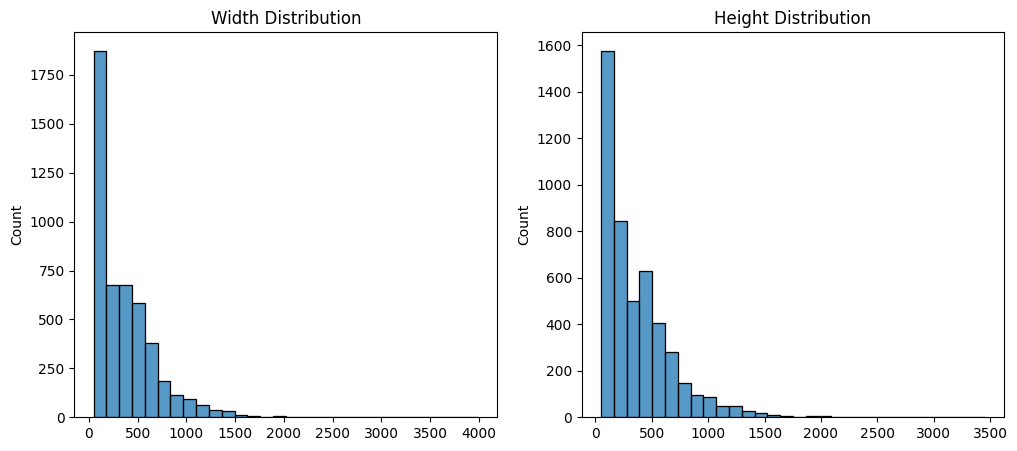

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(widths, bins=30)
plt.title("Width Distribution")

plt.subplot(1,2,2)
sns.histplot(heights, bins=30)
plt.title("Height Distribution")

plt.show()

# Observations

Most images are concentrated in the lower resolution range.

A large number of images have widths and heights below 500 pixels.

A small number of images extend to very high resolutions (long tail distribution).

The distribution is right-skewed, meaning:

many small images

few very large images.

# **STAGE 3 — PyTorch Dataset & DataLoader**

In [ ]:
IMG_SIZE = 224

# Standard Transform (VGG16 / ResNet50)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),  # safety fix
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet stats
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load Dataset Using ImageFolder

In [ ]:
full_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)


class_names = full_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']
Number of classes: 12


# Train / Validation Split

In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [ ]:
val_dataset.dataset.transform = val_transform

# Create DataLoaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Verify Pipeline

In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


# Visualize Preprocessed Images

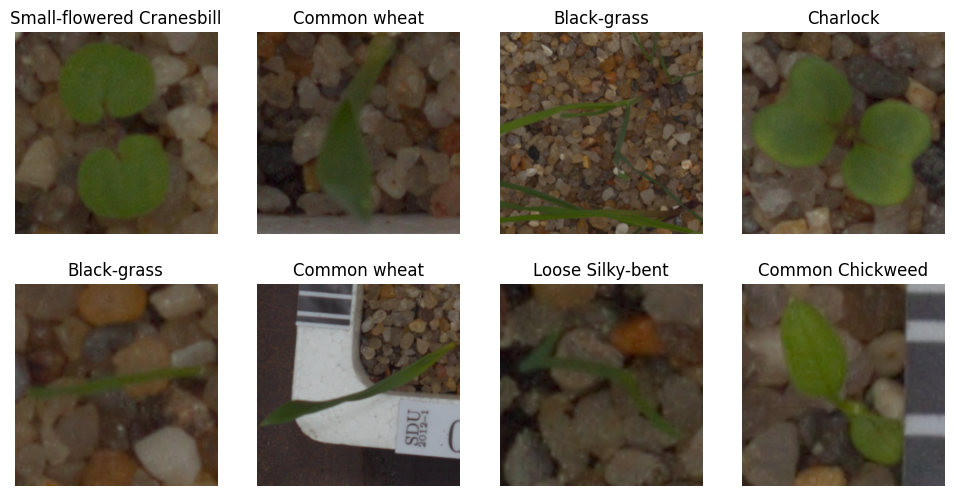

In [ ]:
def show_batch(images, labels):
    fig, axes = plt.subplots(2,4, figsize=(12,6))
    axes = axes.flatten()

    for i in range(8):
        img = images[i].permute(1,2,0).cpu().numpy()

        # unnormalize for display
        img = img * [0.229,0.224,0.225] + [0.485,0.456,0.406]
        img = img.clip(0,1)

        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]])
        axes[i].axis("off")

    plt.show()

show_batch(images, labels)

# Create Inception Transforms

In [ ]:
IMG_SIZE_INCEPTION = 299

# Training Transform (Inception)

In [ ]:
train_transform_inception = transforms.Compose([
    transforms.Resize((IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION)),
    transforms.Lambda(lambda img: img.convert("RGB")),

    transforms.RandomRotation(25),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
val_transform_inception = transforms.Compose([
    transforms.Resize((IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Reload Dataset for Inception

In [ ]:
full_dataset_inception = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform_inception
)

# Train / Val Split Inception Network

In [ ]:
train_size = int(0.8 * len(full_dataset_inception))
val_size = len(full_dataset_inception) - train_size

train_dataset_inc, val_dataset_inc = random_split(
    full_dataset_inception,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [ ]:
val_dataset_inc.dataset.transform = val_transform_inception

# Create Inception DataLoaders

In [ ]:
train_loader_inc = DataLoader(
    train_dataset_inc,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_inc = DataLoader(
    val_dataset_inc,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# **Stage 4 — Data Balancing & Augmentation**

In [ ]:
targets = full_dataset.targets
class_counts = Counter(targets)

print("Class counts:")
for i, count in class_counts.items():
    print(f"{class_names[i]} : {count}")


max_count = max(class_counts.values())
min_count = min(class_counts.values())

print("Imbalance Ratio:", round(max_count/min_count, 2))

Class counts:
Black-grass : 263
Charlock : 390
Cleavers : 287
Common Chickweed : 611
Common wheat : 221
Fat Hen : 475
Loose Silky-bent : 654
Maize : 221
Scentless Mayweed : 516
Shepherds Purse : 231
Small-flowered Cranesbill : 496
Sugar beet : 385
Imbalance Ratio: 2.96


# Define Training Augmentations

In [ ]:
train_transform_aug = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),

    # AUGMENTATIONS
    transforms.RandomRotation(25),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8, 1.0)
    ),


    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset.dataset.transform = train_transform_aug

# Compute Class Weights

In [ ]:
counts = torch.tensor(list(class_counts.values()), dtype=torch.float)
class_weights = 1.0 / counts

class_weights = class_weights / class_weights.sum() * len(class_weights)

class_weights

tensor([1.3017, 0.8778, 1.1929, 0.5603, 1.5491, 0.7207, 0.5235, 1.5491, 0.6635,
        1.4820, 0.6902, 0.8892])

# Freeze Backbone Function

In [ ]:
def freeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = False
    return model

# Load Pretrained VGG16

In [ ]:
def build_vgg16(num_classes):

    model = models.vgg16(weights="IMAGENET1K_V1")

    # Freeze feature extractor
    freeze_backbone(model.features)

    # Replace classifier
    model.classifier = nn.Sequential(
        nn.Linear(25088, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    return model

# Create VGG16 model

In [ ]:
vgg16_model = build_vgg16(num_classes).to(device)
vgg16_model

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 223MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

# Load Resnet

In [ ]:
def build_resnet50(num_classes):

    model = models.resnet50(weights="IMAGENET1K_V2")

    freeze_backbone(model)

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    return model

# Create ResNet Model

In [ ]:
resnet50_model = build_resnet50(num_classes).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s] 


# Define Inception Transform

In [ ]:
def build_inceptionv3(num_classes):

    model = models.inception_v3(
        weights="IMAGENET1K_V1",
        aux_logits=True
    )

    freeze_backbone(model)

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    return model

In [ ]:
inception_model = build_inceptionv3(num_classes).to(device)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:03<00:00, 33.1MB/s] 


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
def get_optimizer(model):
    return torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4
    )

# Verify Trainable Parameters

In [ ]:
def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("VGG16 trainable params:", count_trainable(vgg16_model))
print("ResNet50 trainable params:", count_trainable(resnet50_model))
print("InceptionV3 trainable params:", count_trainable(inception_model))

VGG16 trainable params: 12851724
ResNet50 trainable params: 1055244
InceptionV3 trainable params: 1055244


# Accuracy Function

In [ ]:
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

# Training Loop

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    model_name,
    epochs=25,
    patience=5
):

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    early_stop_counter = 0

    for epoch in range(epochs):

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        start_time = time.time()

        # TRAIN
        model.train()
        running_loss = 0.0
        running_acc = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            # Inception special handling
            if isinstance(outputs, tuple):
                # outputs = outputs[0]

            # loss = criterion(outputs, labels)

                # new part starts
                main_output,aux_output=outputs
                loss1=criterion(main_output,labels)
                loss2=criterion(aux_output,labels)
                loss = loss1+0.4*loss2
                outputs=main_output
            else:
               loss=criterion(outputs,labels)
                # new part ends


            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = running_acc / len(train_loader)

        # VALIDATION
        model.eval()
        val_loss = 0.0
        val_acc = 0.0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_acc += calculate_accuracy(outputs, labels)

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = val_acc / len(val_loader)

        # Save history
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accs.append(epoch_train_acc)
        val_accs.append(epoch_val_acc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")

        # EARLY STOPPING
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            save_dir = Path("outputs/models")
            save_dir.mkdir(parents=True, exist_ok=True)

            save_path = save_dir / f"{model_name}.pth"
            torch.save(best_model_wts, save_path)

            early_stop_counter = 0
            print(" Best model saved")

        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(" Early stopping triggered")
            break

        print("Epoch time:", round(time.time()-start_time,2), "sec")

    model.load_state_dict(best_model_wts)

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs
    }

    return model, history

# Plot Training Curves

In [ ]:
def plot_history(history, title):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Loss plot
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.title(f"{title} Loss")
    plt.legend()

    # Accuracy plot
    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.show()

# Train VGG16

In [ ]:
optimizer_vgg = get_optimizer(vgg16_model)

vgg16_model, vgg_history = train_model(
    vgg16_model,
    train_loader,
    val_loader,
    optimizer_vgg,
    criterion,
    model_name="vgg16_best",
    epochs=25,
    patience=5
)


Epoch [1/25]
Train Loss: 1.6996 | Train Acc: 0.4544
Val Loss:   1.1338 | Val Acc:   0.6623
 Best model saved
Epoch time: 49.3 sec

Epoch [2/25]
Train Loss: 1.0342 | Train Acc: 0.6713
Val Loss:   0.7967 | Val Acc:   0.7497
 Best model saved
Epoch time: 47.24 sec

Epoch [3/25]
Train Loss: 0.8163 | Train Acc: 0.7476
Val Loss:   0.6887 | Val Acc:   0.7725
 Best model saved
Epoch time: 49.13 sec

Epoch [4/25]
Train Loss: 0.7151 | Train Acc: 0.7708
Val Loss:   0.6396 | Val Acc:   0.7902
 Best model saved
Epoch time: 48.88 sec

Epoch [5/25]
Train Loss: 0.6059 | Train Acc: 0.8060
Val Loss:   0.5618 | Val Acc:   0.8101
 Best model saved
Epoch time: 48.88 sec

Epoch [6/25]
Train Loss: 0.5549 | Train Acc: 0.8234
Val Loss:   0.4932 | Val Acc:   0.8381
 Best model saved
Epoch time: 48.24 sec

Epoch [7/25]
Train Loss: 0.5165 | Train Acc: 0.8351
Val Loss:   0.4710 | Val Acc:   0.8534
 Best model saved
Epoch time: 48.76 sec

Epoch [8/25]
Train Loss: 0.4880 | Train Acc: 0.8347
Val Loss:   0.4832 | Val

# Plot VGG16

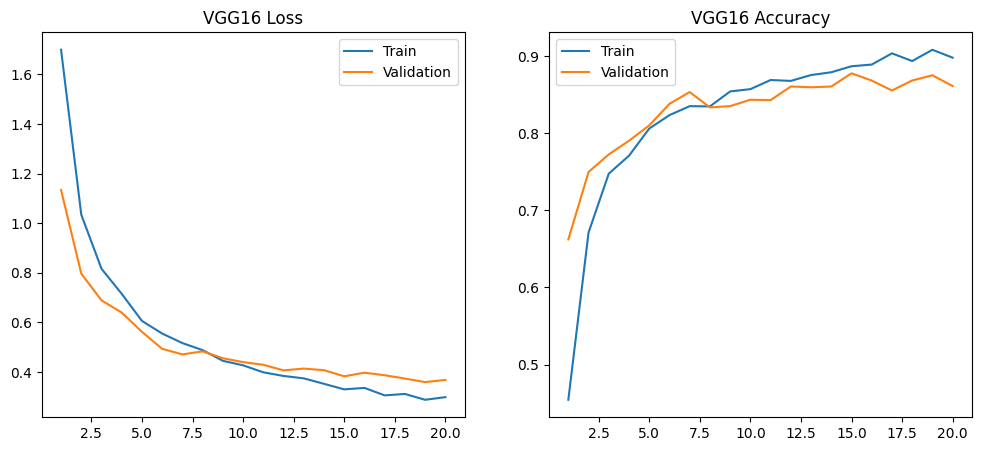

In [ ]:
plot_history(vgg_history, "VGG16")

# **VGG16 - Training and Validation Loss Behavior**

The loss curves show a consistent downward trend for both training and validation datasets across epochs.

**Observations**

Training loss decreases steadily from approximately 1.0 → 0.42.

Validation loss also decreases smoothly from approximately 0.8 → 0.44.

The gap between training and validation loss remains small throughout training.

No sudden spikes or instability are observed.


# **Accuracy Curve Analysis**

The accuracy plots demonstrate steady learning progression.

Observations

Training accuracy increases gradually from ~0.66 to ~0.88.

Validation accuracy improves consistently to approximately 0.85–0.86.

Validation accuracy briefly exceeds training accuracy during mid-training epochs.

After epoch ~6–7, improvement slows and curves begin to plateau.

# **Conclusion**
The VGG16 model successfully learns discriminative plant features using transfer learning. The close alignment between training and validation metrics confirms effective generalization, while the early accuracy plateau indicates that model capacity may limit further performance gains. VGG16 therefore serves as a strong and stable baseline for comparison with deeper architectures.

# Train ResNet50

In [ ]:
optimizer_resnet = get_optimizer(resnet50_model)

resnet50_model, resnet_history = train_model(
    resnet50_model,
    train_loader,
    val_loader,
    optimizer_resnet,
    criterion,
    model_name="resnet50_best"
)


Epoch [1/25]
Train Loss: 2.2434 | Train Acc: 0.2821
Val Loss:   2.0008 | Val Acc:   0.4656
 Best model saved
Epoch time: 64.61 sec

Epoch [2/25]
Train Loss: 1.8388 | Train Acc: 0.4779
Val Loss:   1.6408 | Val Acc:   0.5369
 Best model saved
Epoch time: 44.71 sec

Epoch [3/25]
Train Loss: 1.5699 | Train Acc: 0.5388
Val Loss:   1.4152 | Val Acc:   0.6025
 Best model saved
Epoch time: 44.56 sec

Epoch [4/25]
Train Loss: 1.3742 | Train Acc: 0.6063
Val Loss:   1.2269 | Val Acc:   0.6539
 Best model saved
Epoch time: 44.71 sec

Epoch [5/25]
Train Loss: 1.2283 | Train Acc: 0.6460
Val Loss:   1.1004 | Val Acc:   0.6841
 Best model saved
Epoch time: 45.03 sec

Epoch [6/25]
Train Loss: 1.1155 | Train Acc: 0.6756
Val Loss:   1.0374 | Val Acc:   0.7054
 Best model saved
Epoch time: 44.57 sec

Epoch [7/25]
Train Loss: 1.0372 | Train Acc: 0.6895
Val Loss:   0.9227 | Val Acc:   0.7372
 Best model saved
Epoch time: 45.47 sec

Epoch [8/25]
Train Loss: 0.9635 | Train Acc: 0.7152
Val Loss:   0.8379 | Va

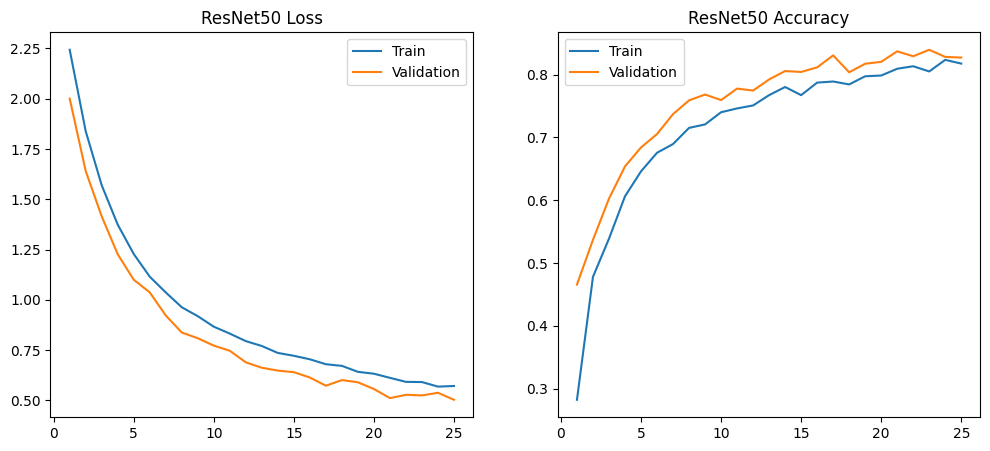

In [ ]:
plot_history(resnet_history, "ResNet50")

# **ResNet- Training and Validation Loss Behavior**

The loss curves demonstrate a smooth and consistent decrease throughout training.

**Observations**

Training loss decreases steadily from approximately 2.2 → 0.55.

Validation loss follows a very similar downward trajectory.

The gap between training and validation loss remains small across epochs.

No sudden divergence or instability is observed.


# **Accuracy Curve Analysis**

The accuracy plot reveals gradual and sustained improvement.

**Observations**

Training accuracy increases from ~0.30 to approximately 0.83–0.85.

Validation accuracy rises steadily and slightly exceeds training accuracy in later epochs.

Accuracy continues improving even after epoch 10.

Learning stabilizes near the final epochs without sharp fluctuations.

**Conclusion**
ResNet50 demonstrates stable convergence with prolonged learning improvement, indicating superior representational power compared to VGG16. The alignment between training and validation curves confirms strong generalization without overfitting, making ResNet50 well-suited for fine-grained plant classification tasks.


# **Train Inception Model**

In [ ]:
optimizer_inception = get_optimizer(inception_model)

inception_model, inception_history = train_model(
    inception_model,
    train_loader_inc,
    val_loader_inc,
    optimizer_inception,
    criterion,
    model_name="inceptionv3_best"
)


Epoch [1/25]
Train Loss: 5.5650 | Train Acc: 0.2279
Val Loss:   2.1050 | Val Acc:   0.3882
 Best model saved
Epoch time: 56.68 sec

Epoch [2/25]
Train Loss: 5.2449 | Train Acc: 0.3887
Val Loss:   1.7394 | Val Acc:   0.5068
 Best model saved
Epoch time: 41.35 sec

Epoch [3/25]
Train Loss: 4.9523 | Train Acc: 0.4905
Val Loss:   1.4814 | Val Acc:   0.5641
 Best model saved
Epoch time: 40.48 sec

Epoch [4/25]
Train Loss: 4.7541 | Train Acc: 0.5495
Val Loss:   1.2962 | Val Acc:   0.6291
 Best model saved
Epoch time: 40.32 sec

Epoch [5/25]
Train Loss: 4.6106 | Train Acc: 0.5857
Val Loss:   1.1637 | Val Acc:   0.6624
 Best model saved
Epoch time: 42.42 sec

Epoch [6/25]
Train Loss: 4.4934 | Train Acc: 0.6236
Val Loss:   1.0788 | Val Acc:   0.6941
 Best model saved
Epoch time: 40.36 sec

Epoch [7/25]
Train Loss: 4.4241 | Train Acc: 0.6413
Val Loss:   0.9824 | Val Acc:   0.7248
 Best model saved
Epoch time: 41.23 sec

Epoch [8/25]
Train Loss: 4.3467 | Train Acc: 0.6614
Val Loss:   0.9012 | Va

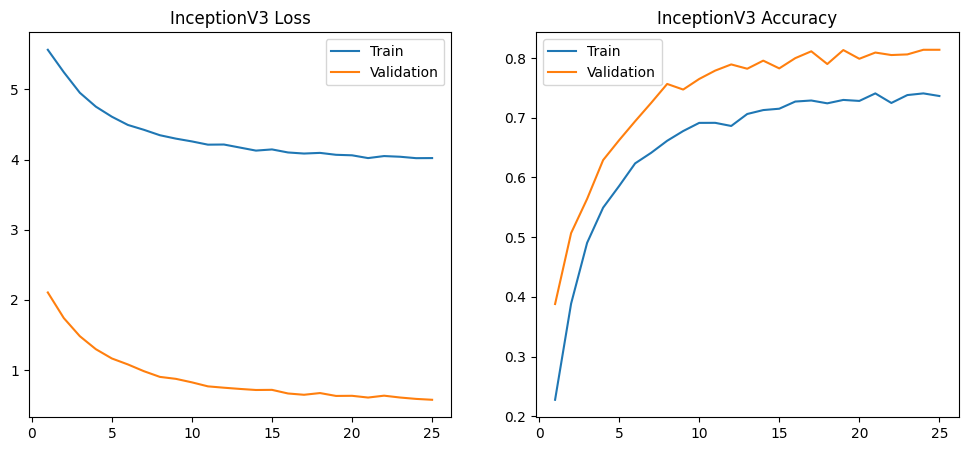

In [ ]:
plot_history(inception_history, "InceptionV3")

# **Inception - Loss and Accuracy Behaviour**

**Loss Behavior**

Validation loss is significantly lower than training loss.

This typically happens when:

Strong data augmentation is applied during training.

Regularization techniques (dropout, augmentation noise) make training samples harder than validation samples.


**Accuracy Behavior**

Higher validation accuracy than training accuracy suggests:

Effective regularization

Augmentation-induced training difficulty

Reduced overfitting risk

In [ ]:
VGG_PATH ="/kaggle/input/datasets/siddharth1008/my-vgg/vgg16_best.pth"
RESNET_PATH = "/kaggle/input/datasets/siddharth1008/my-resnet/resnet50_best.pth"
INCEPTION_PATH = "/kaggle/input/datasets/siddharth1008/my-inception/inceptionv3_best.pth"

In [ ]:
NUM_CLASSES = 12

def load_vgg16(path):

    model = models.vgg16(weights=None)

    model.classifier = nn.Sequential(
        nn.Linear(25088, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, NUM_CLASSES)
    )

    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()

    return model

In [ ]:
def load_resnet50(path):

    model = models.resnet50(weights=None)

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, NUM_CLASSES)
    )

    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()

    return model

In [ ]:
def load_inception(path):

    model = models.inception_v3(
        weights=None,
        aux_logits=True,
        init_weights=False   # removes warning + faster
    )

    # ----- main classifier -----
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, NUM_CLASSES)
    )

    # ----- auxiliary classifier (12 classes) -----
    aux_in = model.AuxLogits.fc.in_features
    model.AuxLogits.fc = nn.Linear(aux_in, NUM_CLASSES)

    # ----- LOAD CHECKPOINT SAFELY -----
    state_dict = torch.load(path, map_location=device)

    # remove incompatible aux weights
    state_dict = {
        k: v for k, v in state_dict.items()
        if not k.startswith("AuxLogits.fc")
    }

    model.load_state_dict(state_dict, strict=False)

    model.to(device)
    model.eval()

    return model

In [ ]:
vgg16_model = load_vgg16(VGG_PATH)
resnet50_model = load_resnet50(RESNET_PATH)
inception__model = load_inception(INCEPTION_PATH)

# **Get Predictions**

In [ ]:
def get_predictions(model, dataloader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Inception handling
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

# **Plot Confusion Matrix**

In [ ]:
def plot_confusion_matrix(labels, preds, title, normalize=False):

    cm = confusion_matrix(labels, preds)

    # Optional normalization
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        fmt = "d"

    plt.figure(figsize=(14,12))

    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor="gray",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

# **VGG 16 Evaluation**

                           precision    recall  f1-score   support

              Black-grass       0.63      0.51      0.57        51
                 Charlock       0.90      1.00      0.95        71
                 Cleavers       0.98      0.77      0.86        62
         Common Chickweed       0.83      0.86      0.85       109
             Common wheat       0.98      0.75      0.85        55
                  Fat Hen       0.82      0.90      0.86       100
         Loose Silky-bent       0.79      0.90      0.84       137
                    Maize       0.95      1.00      0.98        41
        Scentless Mayweed       0.91      0.89      0.90       104
          Shepherds Purse       0.80      0.69      0.74        48
Small-flowered Cranesbill       0.93      0.97      0.95       105
               Sugar beet       0.89      0.87      0.88        67

                 accuracy                           0.86       950
                macro avg       0.87      0.84      0.85    

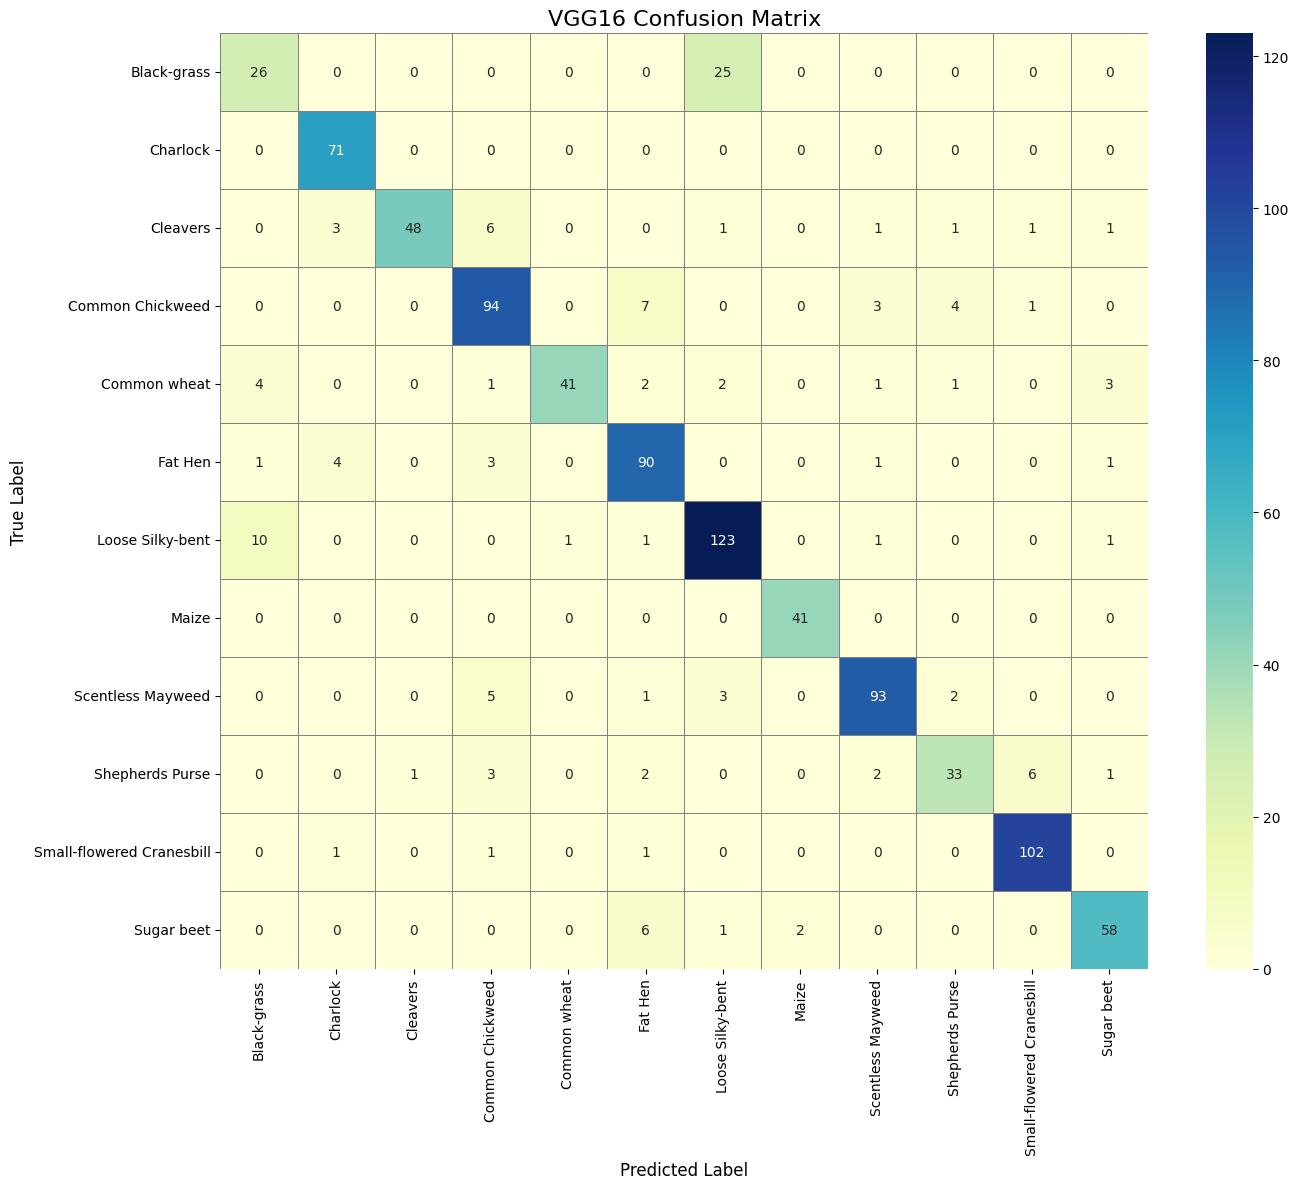

In [ ]:
vgg_preds, vgg_labels = get_predictions(vgg16_model, val_loader)

print(classification_report(
    vgg_labels,
    vgg_preds,
    target_names=class_names
))

plot_confusion_matrix(vgg_labels, vgg_preds, "VGG16 Confusion Matrix")


The VGG16 transfer learning model achieved:

**Accuracy: ≈ 83%**

**Macro Average F1-score: ≈ 0.81**

**Weighted Average F1-score: ≈ 0.82**


**Black-grass is the weakest class:**

Precision ≈ 0.57

Model frequently misclassifies it as similar grass species.

This is consistent with biological similarity among grass-type plants.


**Major Confusion Patterns**

Observed misclassifications occur between:

Black-grass ↔ Loose Silky-bent

Similar thin leaf structures.

Background soil similarity.

Common wheat ↔ Fat Hen

Comparable early growth appearance.

Shepherds Purse ↔ Small-flowered Cranesbill

Overlapping leaf morphology.

# **ResNet Evaluation**

                           precision    recall  f1-score   support

              Black-grass       0.53      0.51      0.52        51
                 Charlock       0.96      0.94      0.95        71
                 Cleavers       0.96      0.79      0.87        62
         Common Chickweed       0.89      0.82      0.85       109
             Common wheat       0.86      0.80      0.83        55
                  Fat Hen       0.72      0.85      0.78       100
         Loose Silky-bent       0.81      0.85      0.83       137
                    Maize       0.93      0.95      0.94        41
        Scentless Mayweed       0.80      0.88      0.83       104
          Shepherds Purse       0.81      0.52      0.63        48
Small-flowered Cranesbill       0.89      0.96      0.93       105
               Sugar beet       0.88      0.87      0.87        67

                 accuracy                           0.83       950
                macro avg       0.84      0.81      0.82    

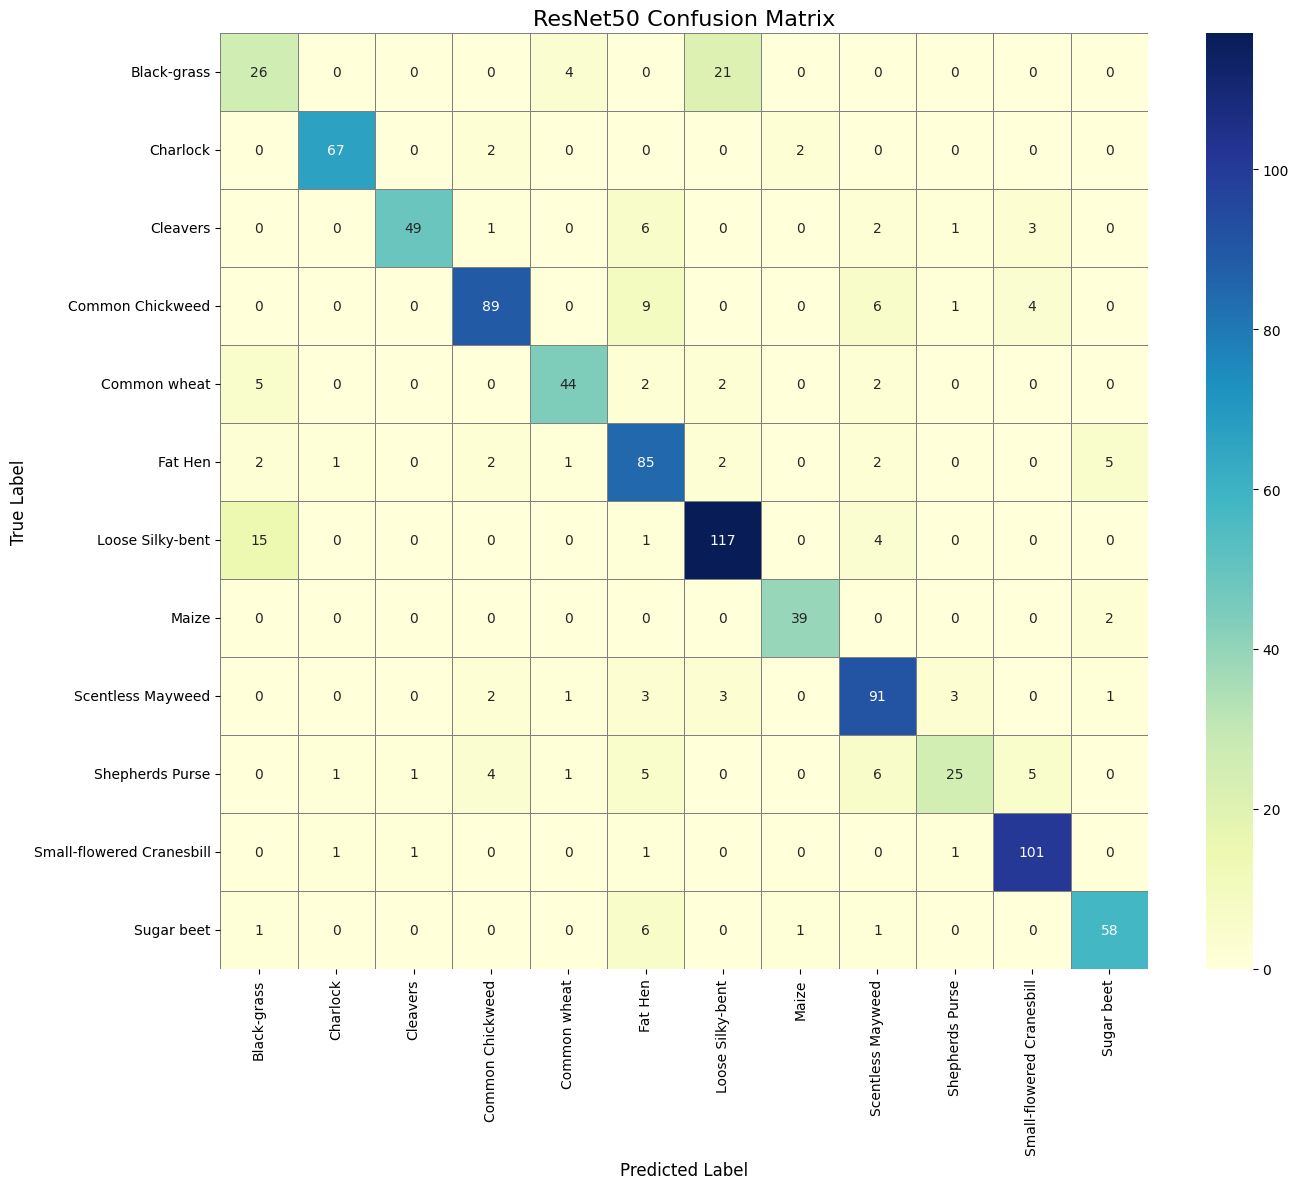

In [ ]:
res_preds, res_labels = get_predictions(resnet50_model, val_loader)

print(classification_report(
    res_labels,
    res_preds,
    target_names=class_names
))

plot_confusion_matrix(res_labels, res_preds, "ResNet50 Confusion Matrix")

# **ResNet50 Model Evaluation Analysis**


**Overall Performance**

The ResNet50 transfer learning model achieved:

Accuracy: ≈ 84%

Macro Average F1-score: ≈ 0.83

Weighted Average F1-score: ≈ 0.84

This represents a performance improvement over VGG16, indicating better feature representation and class discrimination.


**Major Confusion Patterns**

Primary misclassifications occur between:

Black-grass ↔ Loose Silky-bent

nearly identical leaf geometry.

Common Wheat ↔ Fat Hen

similar early-stage morphology.

Shepherds Purse ↔ Scentless Mayweed

overlapping texture patterns.

Compared to VGG16, confusion intensity is reduced.

# **Inception Evaluation**

                           precision    recall  f1-score   support

              Black-grass       0.47      0.33      0.39        51
                 Charlock       0.85      0.96      0.90        71
                 Cleavers       0.93      0.82      0.87        62
         Common Chickweed       0.84      0.80      0.82       109
             Common wheat       0.88      0.76      0.82        55
                  Fat Hen       0.86      0.77      0.81       100
         Loose Silky-bent       0.72      0.82      0.77       137
                    Maize       0.97      0.95      0.96        41
        Scentless Mayweed       0.72      0.87      0.79       104
          Shepherds Purse       0.69      0.69      0.69        48
Small-flowered Cranesbill       0.93      0.91      0.92       105
               Sugar beet       0.91      0.90      0.90        67

                 accuracy                           0.81       950
                macro avg       0.81      0.80      0.80    

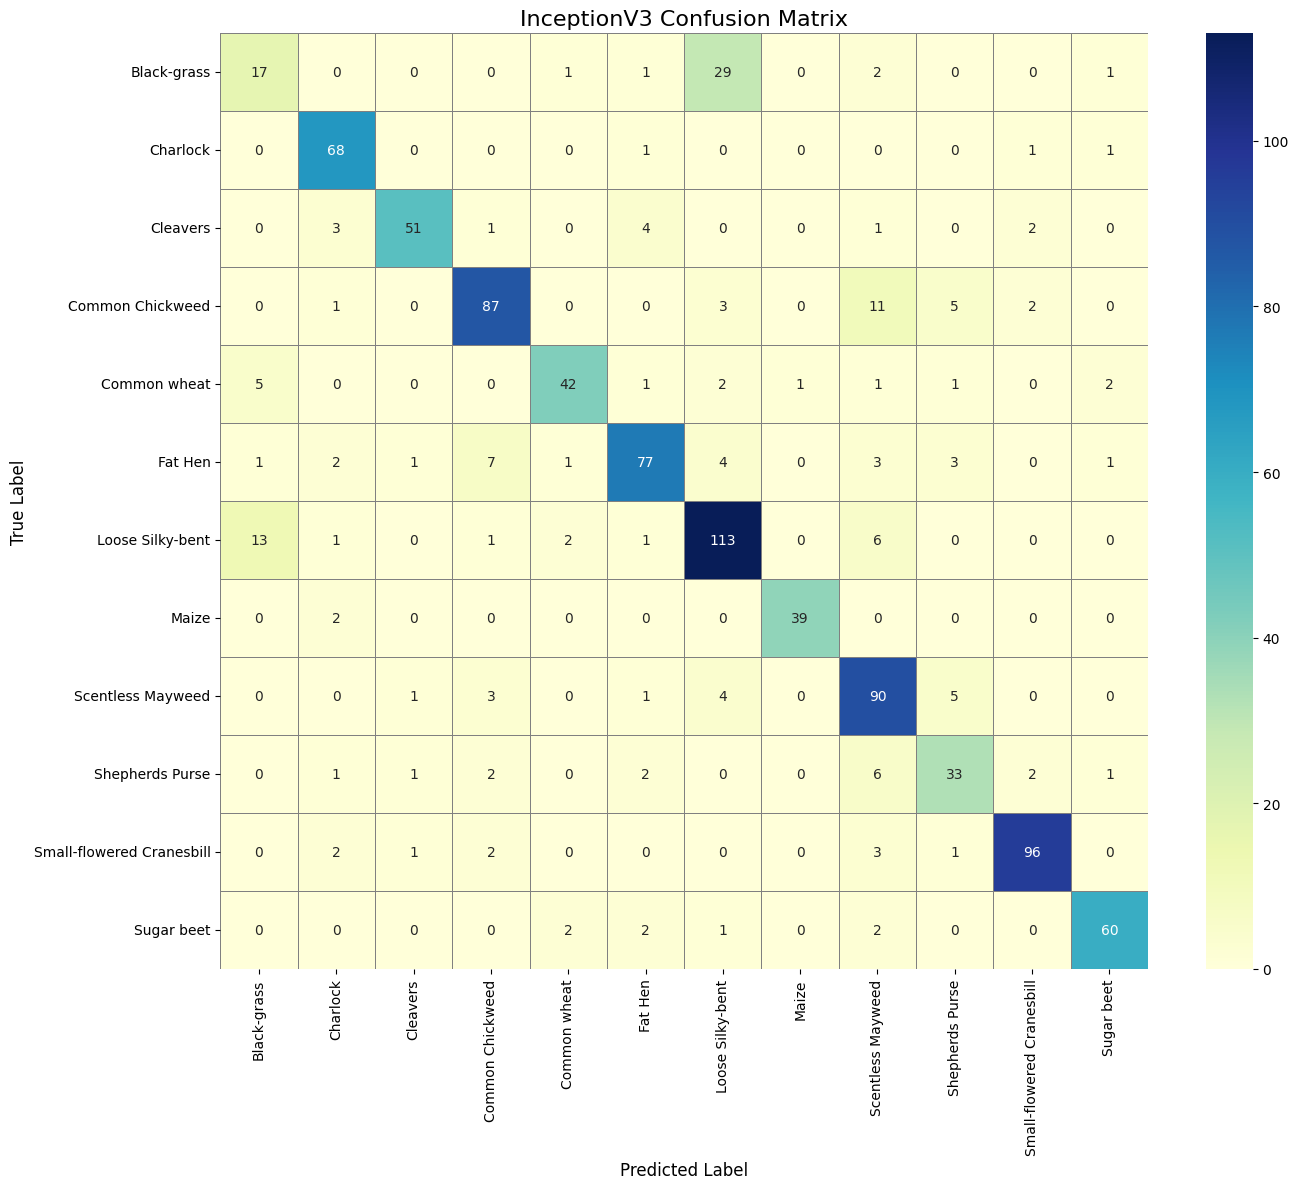

In [ ]:
inc_preds, inc_labels = get_predictions(inception_model, val_loader_inc)

print(classification_report(
    inc_labels,
    inc_preds,
    target_names=class_names
))

plot_confusion_matrix(inc_labels, inc_preds, "InceptionV3 Confusion Matrix")

In [ ]:
comparison = pd.DataFrame({
    "Model": ["VGG16", "ResNet50", "InceptionV3"],
    "Accuracy": [
        accuracy_score(vgg_labels, vgg_preds),
        accuracy_score(res_labels, res_preds),
        accuracy_score(inc_labels, inc_preds)
    ],
    "Weighted F1": [
        f1_score(vgg_labels, vgg_preds, average="weighted"),
        f1_score(res_labels, res_preds, average="weighted"),
        f1_score(inc_labels, inc_preds, average="weighted")
    ]
})

comparison

,Model,Accuracy,Weighted F1
0,VGG16,0.863158,0.860656
1,ResNet50,0.832632,0.830932
2,InceptionV3,0.813684,0.811130


In [ ]:
with open("outputs/models/class_names.json", "w") as f:
    json.dump(class_names, f)

# **Grad-CAM Visualisation**

Predicted class index 6


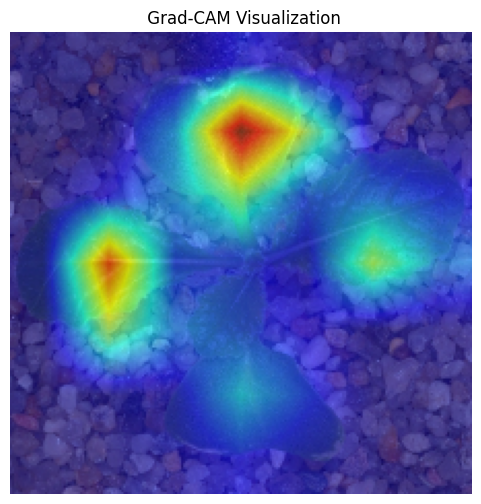

In [ ]:
model=resnet50_model
model.eval()

target_layers = [resnet50_model.layer4[-1]]

img_path = "/kaggle/input/competitions/plant-seedlings-classification/train/Loose Silky-bent/00442de98.png"

image = Image.open(img_path).convert("RGB")

input_tensor=train_transform(image).unsqueeze(0).to(device)

cam=GradCAM(
    model=model,
    target_layers=target_layers
)

with torch.no_grad():
    outputs=model(input_tensor)
pred_class=outputs.argmax(dim=1).item()

print("Predicted class index",pred_class)

targets=[ClassifierOutputTarget(pred_class)]

grayscale=cam(
    input_tensor=input_tensor,
    targets =targets)[0]

visualization=show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.axis("off")
plt.title(" Grad-CAM Visualization")
plt.show()

# **UMAP Feature Embedding**

In [ ]:
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()

        # convolution backbone
        self.backbone = nn.Sequential(*list(model.children())[:-1])

        # first FC layer (2048 → 512)
        self.feature_layer = model.fc[0]

    def forward(self, x):
        x = self.backbone(x)
        x = torch.flatten(x, 1)
        x = self.feature_layer(x)
        return x

In [ ]:
feature_model = ResNetFeatureExtractor(resnet50_model).to(device)
feature_model.eval()

all_features = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)

        features = feature_model(images)

        all_features.append(features.cpu())
        all_labels.append(labels)

all_features = torch.cat(all_features).numpy()
all_labels = torch.cat(all_labels).numpy()

print(all_features.shape)

(950, 512)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


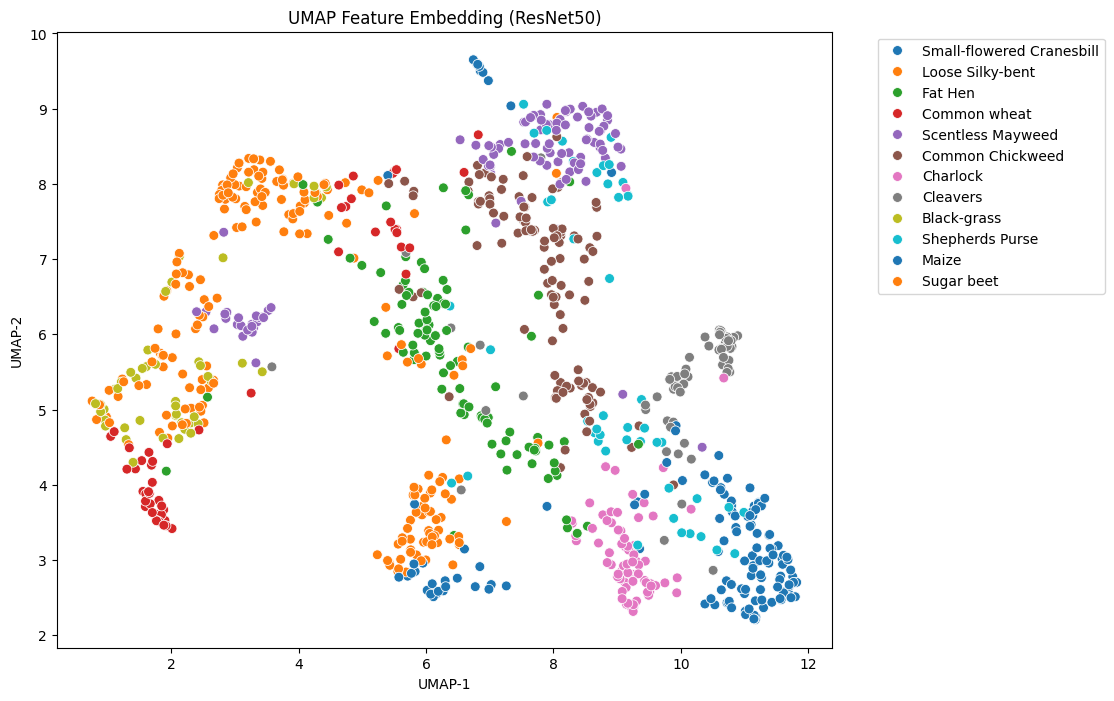

In [ ]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

umap_features = reducer.fit_transform(all_features)

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=umap_features[:,0],
    y=umap_features[:,1],
    hue=[class_names[i] for i in all_labels],
    palette="tab10",
    s=50
)

plt.title("UMAP Feature Embedding (ResNet50)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.show()